In [1]:
import argparse

parser = argparse.ArgumentParser(description="MNIST Influence Experiment")

# Random seed
parser.add_argument('--random_seed', type=int, default=52, help='Random seed') # 52, 12 is great

# Model parameters
parser.add_argument('--model_type', type=str, default='logistic', choices=['logistic', 'mlp', 'attention'], help='Model architecture')
parser.add_argument('--batch_size', type=int, default=128, help='Batch size for training')
parser.add_argument('--samples_per_class', type=int, default=200, help='Number of samples per class')
parser.add_argument('--learning_rate', type=float, default=0.001, help='Learning rate')
parser.add_argument('--epochs', type=int, default=10, help='Number of training epochs')

# Hessian parameters
parser.add_argument('--damping', type=float, default=0.5, help='Damping factor for IHVP')

# PGD parameters
parser.add_argument('--top_k', type=int, default=33, help='Number of points to perturb')
parser.add_argument('--epsilon', type=float, default=1, help='L_∞ budget')
parser.add_argument('--alpha', type=float, default=0.02, help='Step size')
parser.add_argument('--n_steps', type=int, default=50, help='PGD iterations')


args, _ = parser.parse_known_args()

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.4.0+cu121


Files already downloaded and verified
Files already downloaded and verified
torch.Size([3, 32, 32])


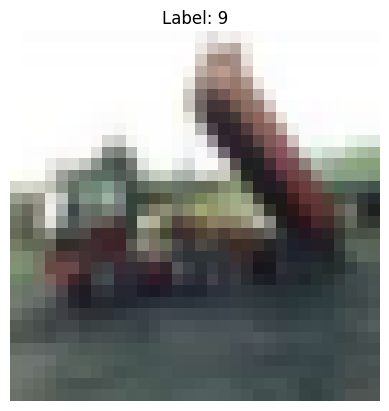

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_ds = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_ds = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# Create a validation split from the training set (e.g., 90% train, 10% val)
num_train = int(0.9 * len(full_train_ds))
num_valid = len(full_train_ds) - num_train
train_ds, valid_ds = random_split(full_train_ds, [num_train, num_valid], generator=torch.Generator().manual_seed(args.random_seed))

img, label = full_train_ds[2]
print(img.shape) # torch.Size([3, 32, 32])
plt.imshow(img.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title(f"Label: {label}")
plt.show()


In [4]:
from dataloader import get_dataloader

train_dl = get_dataloader(train_ds, args.batch_size)
test_dl = get_dataloader(test_ds, args.batch_size)
valid_dl = get_dataloader(valid_ds, args.batch_size)


for i, (xb, yb) in zip(range(10), train_dl):
    print(f"Batch {i} first 5 labels: {yb.tolist()}")
    

Batch 0 first 5 labels: [7, 8, 8, 8, 7, 3, 0, 3, 7, 3, 8, 8, 7, 2, 4, 4, 6, 1, 0, 7, 0, 4, 6, 9, 3, 2, 5, 8, 2, 2, 3, 0, 8, 8, 0, 0, 2, 9, 3, 7, 5, 9, 3, 2, 0, 7, 9, 8, 4, 2, 0, 1, 3, 3, 1, 3, 7, 8, 2, 5, 2, 9, 6, 8, 2, 6, 7, 3, 4, 0, 4, 1, 0, 3, 2, 6, 7, 2, 8, 9, 0, 8, 4, 4, 0, 5, 8, 3, 7, 2, 8, 4, 6, 7, 2, 0, 7, 7, 7, 1, 7, 7, 3, 2, 6, 5, 4, 1, 3, 4, 0, 1, 8, 4, 4, 5, 1, 0, 2, 6, 7, 4, 4, 3, 7, 4, 7, 1]
Batch 1 first 5 labels: [4, 9, 8, 4, 0, 2, 8, 2, 2, 8, 2, 5, 1, 9, 9, 9, 5, 0, 4, 3, 8, 3, 7, 6, 0, 9, 2, 4, 9, 6, 6, 9, 5, 4, 5, 7, 8, 1, 3, 9, 4, 0, 4, 0, 8, 5, 4, 2, 6, 7, 8, 3, 3, 8, 6, 4, 4, 2, 7, 6, 8, 9, 2, 8, 7, 6, 5, 5, 0, 1, 6, 9, 2, 9, 4, 7, 6, 8, 9, 5, 1, 7, 7, 8, 0, 3, 0, 2, 1, 5, 0, 2, 9, 1, 8, 3, 5, 2, 1, 9, 7, 5, 1, 1, 2, 6, 0, 8, 0, 2, 2, 1, 7, 0, 7, 0, 7, 9, 6, 9, 9, 8, 2, 8, 4, 1, 1, 4]
Batch 2 first 5 labels: [0, 3, 8, 7, 9, 6, 6, 7, 0, 0, 9, 7, 3, 8, 1, 9, 3, 6, 6, 0, 9, 7, 8, 1, 8, 8, 4, 3, 1, 5, 0, 4, 0, 7, 2, 8, 9, 1, 0, 9, 8, 6, 5, 9, 9, 6, 3, 4, 5, 5, 1, 1, 1

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    """Residual block with batch normalization"""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class CNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10, img_size=28):
        """
        Improved CNN with residual connections and batch normalization.

        Args:
            in_channels (int): Number of image input channels (1 for MNIST, 3 for CIFAR).
            num_classes (int): Number of output classes.
            img_size (int): Height/Width of input images (assumes square).
        """
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.img_size = img_size

        # Initial convolution
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Residual blocks
        self.layer1 = self._make_layer(32, 32, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(32, 64, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(64, 128, num_blocks=2, stride=2)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.3)
        
        # Final fully connected layer
        self.fc = nn.Linear(128, num_classes)
    
    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, xb):
        out = F.relu(self.bn1(self.conv1(xb)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.adaptive_avg_pool2d(out, 1)
        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        out = self.fc(out)
        return out

0 1.3912605863783094 1.3367390119552611
1 0.9606308746443855 1.229456141281128
2 0.7764738053003947 0.9218253982543946
3 0.6446938252343072 0.7195550959587097
4 0.5535348099814521 0.6847527860403061
5 0.47735879775153267 0.6614611628055572
6 0.41267922032409243 0.6865648201942444
7 0.3529545793559816 0.829048884344101
8 0.3020222724199295 0.8584510673999787
9 0.2633904161347283 1.060065048789978


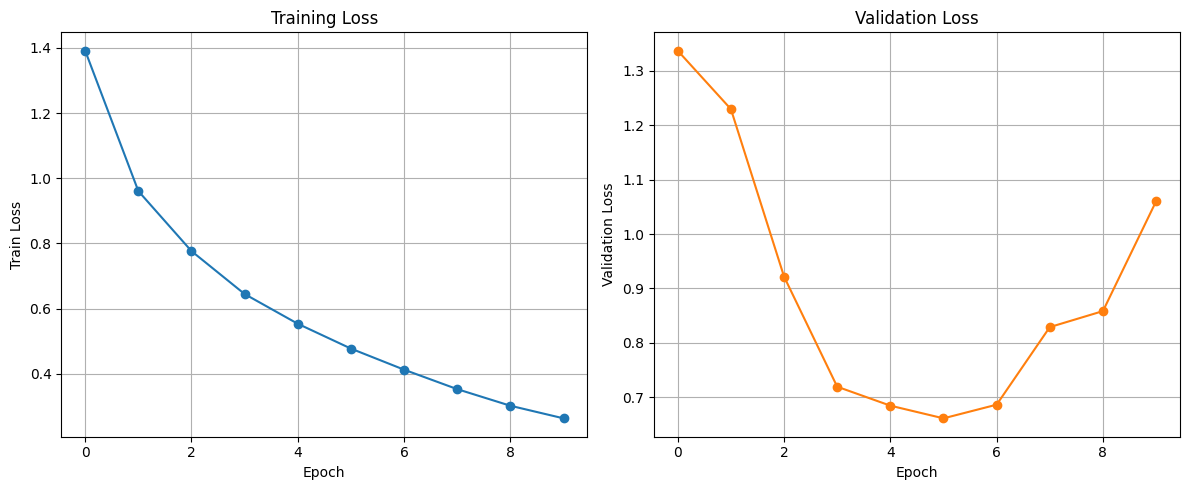

In [6]:
from train import fit

in_channels = full_train_ds[0][0].shape[0]
img_size = full_train_ds[0][0].shape[1]
num_classes = len(full_train_ds.classes)

model = CNN(in_channels=in_channels, num_classes=num_classes, img_size=img_size).to(device)

# Use Adam optimizer with learning rate scheduling
opt = torch.optim.Adam(model.parameters(), lr=args.learning_rate, weight_decay=1e-4)

loss_func = nn.CrossEntropyLoss()

fit(args.epochs, model, loss_func, opt, train_dl, valid_dl)

In [7]:
# Calculate model accuracy on the test set
correct = 0
total = 0
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        predicted = outputs.argmax(dim=-1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy * 100:.2f}%")

Test accuracy: 71.10%
